# Self-supervised Finetuning on Xenium Data

Adapt a pretrained TERRA model to **your own Xenium data** with **self-supervised LoRA fine-tuning** — no labels required — then embed and cluster with the adapted model. This continues TERRA's self-supervised pretraining objective on your data while training only small **LoRA adapters** on the frozen backbone: fast, data-efficient, and non-destructive.

**You will:**
1. Download a public single-cell-resolution Xenium sample (the same one as the quickstart).
2. Download a pretrained TERRA model from the Hugging Face Hub.
3. Tokenize the data for fine-tuning.
4. Fine-tune the encoder with self-supervised LoRA adapters.
5. Merge the adapters into a self-contained, embeddable model.
6. Embed with the adapted model and cluster.

:::{note}
**TERRA requires an NVIDIA GPU** for the tokenization, fine-tuning and embedding steps.
:::

New to TERRA? Start with the {doc}`zero-shot quickstart <zero_shot_quickstart>` first.

## 1. Setup

In [ ]:
# Colab / fresh environment only. Skip if you already installed TERRA per the installation guide.
%pip install terra-st

In [1]:
import logging
from pathlib import Path

import numpy as np
import scanpy as sc

from terra import (download_pretrained, harmonize_adata, tokenize_adata,
                   harmonize_tokenize_embed_pipeline)
from terra.datasets import read_xenium_10x
from terra.training.finetune_self_supervised import (
    finetune_self_supervised, prepare_finetuned_model)

logging.basicConfig(level="INFO")  # see TERRA progress
sc.settings.set_figure_params(dpi=80, frameon=False)

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 2. Download the demo dataset

We use the 10x Genomics **Xenium Prime FFPE Human Skin** sample — the same public dataset as the {doc}`zero-shot quickstart <zero_shot_quickstart>`. Swap in your own raw-count Xenium `AnnData` (spatial coordinates in `obsm["spatial"]`) to fine-tune on your data.

In [2]:
# Xenium Prime FFPE Human Skin (5,000-gene panel). The reader downloads two
# small standalone files (~44 MB) on first run and caches them.
adata = read_xenium_10x(
    "https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Human_Skin_FFPE/Xenium_Prime_Human_Skin_FFPE",
    "data/xenium_skin",
)
adata.obs["cell_id"] = adata.obs_names.astype(str)
adata.obs["sample"] = "skin"

# Crop a contiguous tissue window (so spatial neighborhoods stay intact) to keep
# the demo fast. Widen `half_window` (microns) to fine-tune on more cells.
xy = adata.obsm["spatial"]
center = np.median(xy, axis=0)
half_window = 400
adata = adata[(np.abs(xy - center) <= half_window).all(axis=1)].copy()
print(adata)

AnnData object with n_obs × n_vars = 5119 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'cell_id', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


## 3. Download a pretrained TERRA model

`download_pretrained` fetches a self-contained model bundle (checkpoint, tokenizer, and the gene-reference files used for harmonization) and returns the local folder path.

In [3]:
# By default the model is cached in the Hugging Face cache; pass
# local_dir="terra_model" to download it into a folder of your choice.
model_dir = download_pretrained("Lotfollahi-lab/TERRA-96M")

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Lotfollahi-lab/TERRA-96M/revision/main "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-96M/revision/main "HTTP/1.1 200 OK"


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

## 4. Tokenize for fine-tuning

Fine-tuning trains on **tokenized** data. We harmonize a copy of the sample (map genes to the model's Ensembl vocabulary + QC), tokenize it, and save it to disk. We keep the raw `adata` to embed later with the adapted model.

In [4]:
# Reproduce the model's training-time gene mapping/filtering with the reference
# files shipped in the bundle.
gene_mapping_dict_file_path = str(Path(model_dir) / "ensembl_dictionary.pkl")
gene_occurrence_count_file_path = str(Path(model_dir) / "gene_count_dictionary.pkl")

adata_ft = harmonize_adata(
    adata.copy(),
    gene_mapping_dict_file_path=gene_mapping_dict_file_path,
    gene_occurrence_count_file_path=gene_occurrence_count_file_path,
    species="human",
    min_cells_per_gene=0,
    min_genes_per_cell=0,
)
dataset = tokenize_adata(adata_ft, model_folder_path=model_dir,
                         cache_directory_path="./terra_cache")

tokenised_dir = "data/xenium_skin_tokenised"
dataset.save_to_disk(tokenised_dir)
print(f"tokenised {len(dataset):,} cells -> {tokenised_dir}")

INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-96M/snapshots/f3a0ea8b0827fc9d49bea5de27e80f0cbf0214bc/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 4957.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 0 genes.
INFO:terra.inference.harmonize:Before cell filtering: 5119 cells.
INFO:terra.inference.harmonize:After cell filtering: 5119 cells (removed 0 cells).
INFO:terra.infere

Setting num_proc from 4 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Generating train split: 0 examples [00:00, ? examples/s]

INFO:terra.tokenizers.cell_tokenizers:Formatting gene tokens...


Map (num_proc=4):   0%|          | 0/5119 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5119 [00:00<?, ? examples/s]

tokenised 5,119 cells -> data/xenium_skin_tokenised


## 5. Fine-tune with LoRA (self-supervised)

Only the **LoRA adapters** on the attention/MLP projections are trained; the pretrained weights stay frozen. The config below mirrors the pretraining schedule, with a few epochs for this small demo crop — scale `num_epochs` and the data up for real adaptation.

In [5]:
args = {
    "model": {
        "pretrained_checkpoint_path": model_dir,
        "finetune_checkpoint_path": "data/xenium_finetune",
    },
    "data": {
        "finetune_dataset": [tokenised_dir],
        "batch_size": 128,
        "num_workers": 8,
        "pin_memory": True,
        "drop_last": True,
        "sample_segments": False,
        "sample_gene_masks": True,
    },
    "finetune": {
        "num_epochs": 5,
        "lr": 1e-3,
        "start_lr": 1e-5,
        "final_lr": 1e-5,
        "warmup_epochs": 1,
        "weight_decay": 0.04,
        "final_weight_decay": 0.4,
        "ema_momentum": 0.9995,        # EMA for the target encoder
        "final_ema_momentum": 1.0,
        "loss_fn_type": "smooth_l1",
        "clip_grad": 2.0,
        "use_bfloat16": True,

        # LoRA (parameter-efficient fine-tuning)
        "use_peft": True,
        "peft_method": "lora",
        "peft_rank": 16,
        "peft_alpha": 256,
        "peft_dropout": 0.1,
        "peft_bias": "none",
        "peft_target_modules": ["qkv", "proj", "fc1", "fc2"],
        "save_every": 1,               # checkpoint every epoch
    },
}

# dataset=None -> the tokenised dataset listed in args["data"]["finetune_dataset"]
# is loaded automatically.
run_dir = finetune_self_supervised(args=args, dataset=None, run_name="xenium_finetune")

INFO:terra.training.finetune_self_supervised:Loading 1 dataset(s)...
INFO:terra.training.finetune_self_supervised:Loading dataset 1/1: data/xenium_skin_tokenised
INFO:terra.training.finetune_self_supervised:Loaded 5119 samples
INFO:terra.datasets.dataloaders:Dataloader and -sampler created.
INFO:terra.training.finetune_self_supervised:Initializing encoder, predictor, and target encoder...


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
    (pos_embed): Embedding(2



  0%|                                                          | 0/39 [00:00<?, ?it/s]

INFO:terra.training.finetune_self_supervised:Epoch 1, Batch 1: Grad norm - Encoder: 1.4711, Predictor: 0.7860
INFO:terra.training.finetune_self_supervised:Current LR: 0.000035, WD: 0.040015


...

  0%|                                                          | 0/39 [00:00<?, ?it/s]

INFO:terra.training.finetune_self_supervised:Epoch 5, Batch 1: Grad norm - Encoder: 0.0930, Predictor: 0.0256
INFO:terra.training.finetune_self_supervised:Current LR: 0.000384, WD: 0.299742


100%|█████████████████████████████████████████████████| 39/39 [00:53<00:00,  1.38s/it]

INFO:terra.training.finetune_self_supervised:Epoch [5/5], Loss: 0.2586, LR: 0.000139


INFO:terra.training.finetune_self_supervised:Checkpoint saved to data/xenium_finetune/xenium_finetune/checkpoint_epoch_5.pt
INFO:terra.training.finetune_self_supervised:Checkpoint saved to data/xenium_finetune/xenium_finetune/checkpoint_epoch_5.pt
INFO:terra.training.finetune_self_supervised:Fine-tuning complete!


:::{note}
This is a tiny demo crop, so it runs quickly. Real adaptation uses more cells and
epochs and is a multi-hour GPU job.
:::

## 6. Merge the LoRA adapters

`prepare_finetuned_model` folds the adapters into the base weights and writes a self-contained model folder (`model_config.yaml`, `token_dictionary.pkl`, `model_checkpoint.pt`) that the embedding pipeline can consume directly.

In [6]:
finetuned_model_dir = "data/xenium_lora_merged"
prepare_finetuned_model(
    finetuned_checkpoint_dir=run_dir,   # returned by finetune_self_supervised above
    pretrained_model_dir=model_dir,
    output_dir=finetuned_model_dir,
    use_peft=True,
)

INFO:terra.training.finetune_self_supervised:Loading finetuned checkpoint: data/xenium_finetune/xenium_finetune/checkpoint_epoch_5.pt
INFO:terra.training.finetune_self_supervised:Merging LoRA adapters into the base model...
INFO:terra.training.finetune_self_supervised:Merged 50 LoRA adapter layers (152 total layers)
INFO:terra.training.finetune_self_supervised:Merged 48 LoRA adapter layers (154 total layers)
INFO:terra.training.finetune_self_supervised:Prepared embeddable model at data/xenium_lora_merged


'data/xenium_lora_merged'

## 7. Embed with the adapted model

`harmonize_tokenize_embed_pipeline` runs the full harmonize → tokenize → embed workflow in one call and stores the embeddings in `adata.obsm`. Point `model_folder_path` at the **adapted** model. (Point it at `model_dir` instead to compare against the pretrained model.)

In [7]:
adata = harmonize_tokenize_embed_pipeline(
    adata=adata,
    sample_key=None,          # a single sample
    batch_key="sample",
    model_folder_path=finetuned_model_dir,
    cache_directory_path="./terra_cache",
    batch_size=128,           # lower this if you run out of GPU memory
)
# Embeddings now live in adata.obsm:
#   "cell_emb"         -> each cell's own expression
#   "neighborhood_emb" -> the cell together with its spatial neighborhood
print(list(adata.obsm))

INFO:terra.inference.embed:Harmonizing AnnData...
INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `data/xenium_lora_merged/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 4957.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 0 genes.
INFO:terra.inference.harmonize:Before cell filtering: 5119 cells.
INFO:terra.inference.harmonize:After cell filtering: 5119 cells (removed 0 cells).
INFO:terra.inference.harmonize:Filtering genes expressed in less than 0 c

Map (num_proc=4):   0%|          | 0/5119 [00:00<?, ? examples/s]

INFO:terra.inference.embed:Embedding tokenized data...
INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
   

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 5 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: data/xenium_lora_merged/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
40it [01:09,  1.74s/it]

INFO:terra.inference.embed:Embedded tokenized data.
['spatial', 'cell_emb', 'neighborhood_emb', 'spatial_cell_emb']


## 8. Cluster & visualize

Cluster the **neighborhood** embedding to find spatial niches and the **cell** embedding to find cell types, then view each on its UMAP.

... storing 'segmentation_method' as categorical
... storing 'sample' as categorical


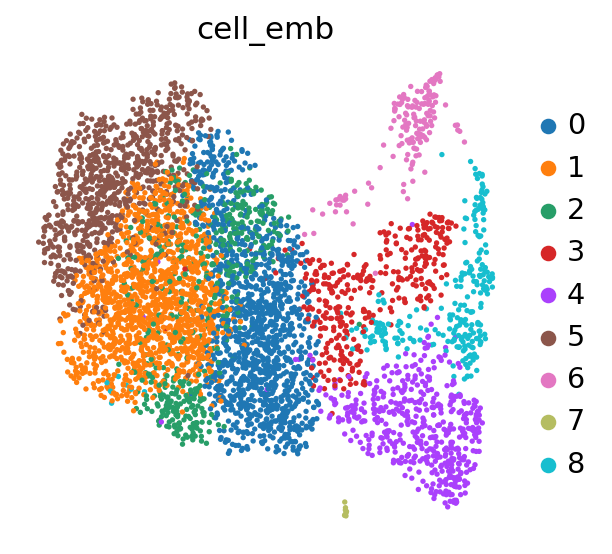

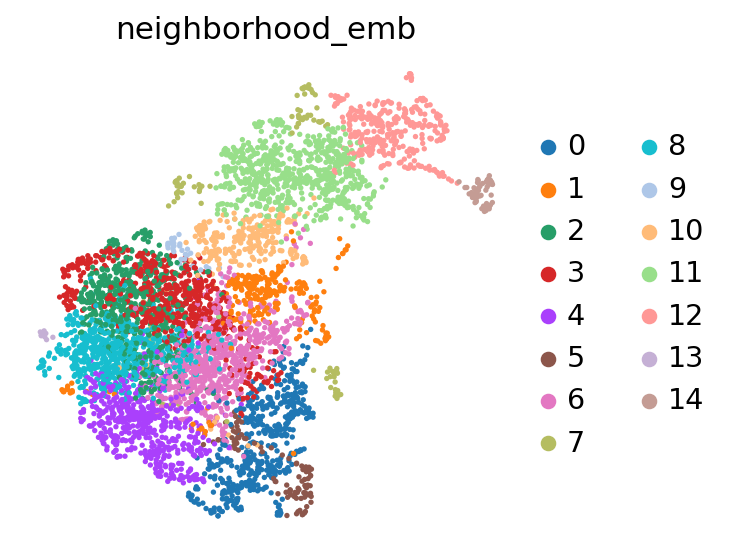

In [8]:
for emb_key in ["cell_emb", "neighborhood_emb"]:
    sc.pp.neighbors(adata, use_rep=emb_key, key_added=emb_key)
    sc.tl.leiden(adata, neighbors_key=emb_key, key_added=emb_key + "_cluster",
                 resolution=0.6, flavor="igraph", n_iterations=2, directed=False)
    sc.tl.umap(adata, neighbors_key=emb_key)
    sc.pl.umap(adata, neighbors_key=emb_key, color=emb_key + "_cluster",
               title=emb_key)

## Next steps

- {doc}`supervised_finetuning` — fine-tune with a classification head for label transfer.
- {doc}`visium_transfer_learning_tutorial` — adapt the model across platforms (Xenium → Visium).
- {doc}`downstream_analysis` — gene-level embeddings, spatial gene-pair scoring, and perturbation.

**Questions or issues?** Please report them on the [TERRA GitHub repository](https://github.com/Lotfollahi-lab/terra/issues).